# Simulated Annealing

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

random.seed(70)

In [31]:
def draw_circuit(coords, circuit):
    """
    Draw a circuit through every point from a list of coordinants
    and the order of the circuit. The circuit will automatically 
    connect to the starting point.
    Note the input circuit must start with 1.
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    circuit.append(1)
    route_idx = np.array(circuit) - 1
    reordered = coords[route_idx]

    ax.plot(reordered[:,0], reordered[:,1], 'bo-', lw=1, ms=5)

    for idx in set(route_idx):
        ax.annotate(idx + 1, (coords[idx, 0], coords[idx, 1]), textcoords="offset points", xytext=(5, 5), fontsize=9)

    ax.set_title(f"TSP Circuit(Total Distance: {calc_dist(coords, circuit):.2f})")
    ax.grid(True, ls='--')
    plt.show()

def calc_dist(coords, circuit):
    """
    Calculate the total length of the circuit from a list of coordinants
    and the order of the circuit.
    Note the circuit must start with 1
    """
    circuit.append(1)
    route_idx = np.array(circuit) - 1
    reordered = coords[route_idx]

    diffs = np.diff(reordered, axis=0)
    return np.sqrt((diffs**2).sum(axis=1)).sum()


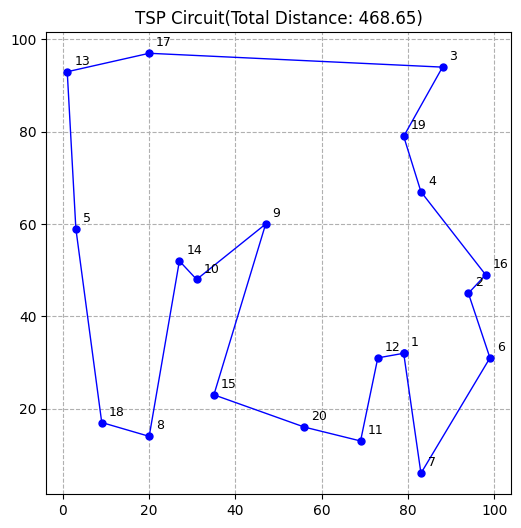

In [43]:
city_pos = np.loadtxt("data.txt", delimiter=',')
circ = [1,12,11,20,15,9,10,14,8,18,5,13,17,3,19,4,16,2,6,7]
draw_circuit(city_pos, circ)

Implementation of Simulated Annealing on constant coefficient of Temperature and Metropolis-Hastings Criterion

In [65]:
def two_opt(circuit, a, b):
    pos1 = min(a, b)
    pos2 = max(a, b)
    return circuit[:pos1+1] + circuit[pos1+1:pos2+1][::-1] + circuit[pos2+1:]

circ = [1,12,11,20,15,9,10,14,8,18,5,13,17,3,19,4,16,2,6,7]
print(circ)
print(two_opt(circ, 1, 4))
print(random.randint(1, 20))

def proba_boltzmann(delta, temp):
    return 1.0 if delta < 0 else math.exp(-delta/temp)

[1, 12, 11, 20, 15, 9, 10, 14, 8, 18, 5, 13, 17, 3, 19, 4, 16, 2, 6, 7]
[1, 12, 15, 20, 11, 9, 10, 14, 8, 18, 5, 13, 17, 3, 19, 4, 16, 2, 6, 7]
4


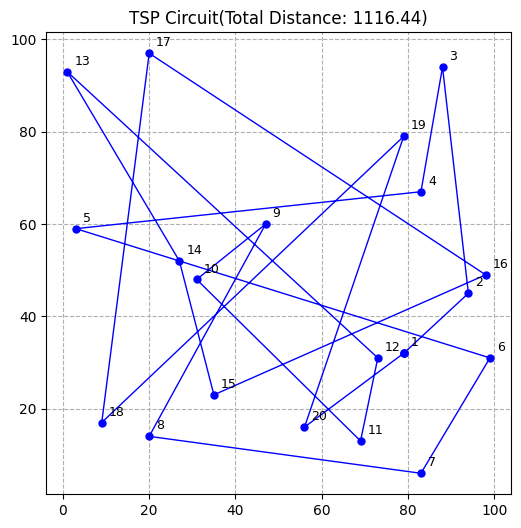

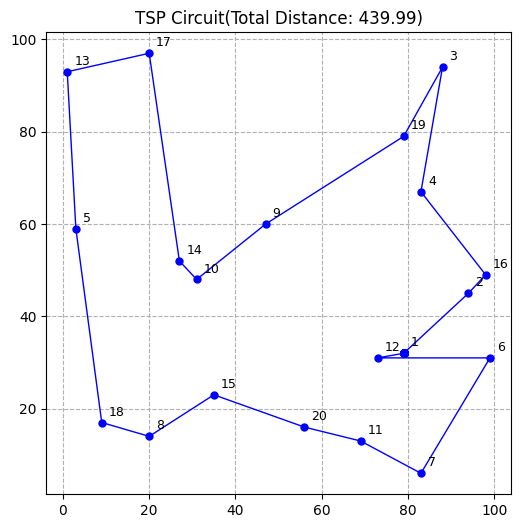

In [77]:
def simulated_annealing(coords, init_temp, cooling_rate, min_temp,
                        snapshot_temps=None):

    n = len(coords)
    circuit = list(range(1,n+1))
    cost = calc_dist(coords, circuit)
    # circuit = list(range(2,n+1))
    # random.shuffle(circuit)
    # circuit.insert(0, 1)

    draw_circuit(city_pos, circuit)

    temp = init_temp
    while temp > min_temp:
        neighbor = two_opt(circuit, random.randint(1, n-1), random.randint(1, n-1))
        neighbor_cost = calc_dist(coords, neighbor)
        delta = neighbor_cost - cost

        if neighbor_cost < cost or random.random() < proba_boltzmann(delta, temp):
            circuit = neighbor
            cost = neighbor_cost

        temp *= cooling_rate
    
    draw_circuit(coords, circuit)

simulated_annealing(city_pos, 10000, 0.999, 1)